# Import LagrangianTraj_MF package

In [442]:
# Import LagrangianTraj_MF 
%run LagrangianTraj_MF.ipynb

# Model data

This part needs to be adapted depending on your model files.
 - For ARPEGE: please, use different grib files, containing the entire dataset (u,v,w,etc) for each time steps. 

#### Dimension definition

In [443]:
# Name of longitude, latitude, pressure dimensions in the model file
list_coord=['longitude','latitude','isobaricInhPa'] 

# Initial time of forecast
Initial_time_model='2016-10-01T12:00:00.000000000'

# Forecast term
Forecast_term=48 # in hours

# Format of time : %Y:year, %m:month,%d:day, %H:hour, %M:minute, %S:second
time_format='%Y-%m-%dT%H:%M:%S.000000000'

# End of forecast (do not modified)
End_time_model=End_time(Initial_time_model, time_format, Forecast_term)

# Time between two model outputs (in hour)
dt_modelOutput =0.25 

# List of model time (no need to be modified)
YYMMDDHH_model=TimeList(Initial_time_model, 1 , 
                        dt_modelOutput, time_format, 
                        time_end=End_time_model,
                        format_output=time_format)

#### Define model files

In [444]:
# Root where all model files are stored
root_exp="/home/wimmerm/NAWDEX/Data/fc_000/"

# File names (list of files)
file_names=[root_exp + "GRIDHSTGLOB05+" +str(i).zfill(4) for i in range(0,218,2)]

# File type
file_type='grib'

#### Read model data

In [445]:
# Open file (do not modify)
file_data,LON_model, LAT_model, PRE_model,list_coord=read_model(root_exp,file_names, 'grib',list_coord,
                                                    longitude_slice=(-70,25), latitude_slice=(30,80),
                                                    grib_selection={'typeOfLevel': 'isobaricInhPa'})


# -------------------------------------------------------------------------------------------------------
#                                     COMMENT THE FOLLOWING LINES 
#                  ONLY IF W IS ON THE SAME PRESSURE LEVELS THAN THE OTHER VARIABLES
# -------------------------------------------------------------------------------------------------------

# -------------------------------------------------------------------------------------------------------
# Solution #1: Delete the pressure level on which w does not exist
# -------------------------------------------------------------------------------------------------------
# For all variables, delete vertical levels that doesn't exist in w
#file_data11=file_data.isel(pressure=slice(0,2,1))
#file_data12=file_data.isel(pressure=slice(3,21,1))
#file_data1= xr.concat([file_data11,file_data12], dim='pressure')
#file_data2,LON_model, LAT_model, PRE_modelW=read_model(root_exp,file_names, 'grib',list_coord,
#                                                    longitude_slice=(-70,10), latitude_slice=(30,80),
#                                                    grib_selection={'shortName': 'w'})

# -------------------------------------------------------------------------------------------------------
# Solution #2: Consider w on another pressure dimension
# -------------------------------------------------------------------------------------------------------
list_coord=['longitude','latitude','isobaricInhPa']  
file_data2,LON_model, LAT_model, PRE_modelW, list_coord=read_model(root_exp,file_names, file_type,list_coord,
                                                    longitude_slice=(-70,25), latitude_slice=(30,80),
                                                    grib_selection={'shortName': 'w'})
list_coord+=['pressure2']
file_data2=file_data2.rename_dims({'pressure':'pressure2'})
file_data2=file_data2.rename({'pressure':'pressure2'})

# -------------------------------------------------------------------------------------------------------
# Merge all variable in one xarray
# -------------------------------------------------------------------------------------------------------
file_data= xr.merge([file_data, file_data2])


skipping variable: paramId==135 shortName='w'
Traceback (most recent call last):
  File "/home/wimmerm/venv/lib/python3.12/site-packages/cfgrib/dataset.py", line 725, in build_dataset_components
    dict_merge(variables, coord_vars)
  File "/home/wimmerm/venv/lib/python3.12/site-packages/cfgrib/dataset.py", line 641, in dict_merge
    raise DatasetBuildError(
cfgrib.dataset.DatasetBuildError: key present and new value is different: key='isobaricInhPa' value=Variable(dimensions=('isobaricInhPa',), data=array([1000.,  950.,  925.,  900.,  850.,  800.,  750.,  700.,  650.,
        600.,  550.,  500.,  450.,  400.,  350.,  300.,  250.,  200.,
        150.,  100.,   50.])) new_value=Variable(dimensions=('isobaricInhPa',), data=array([1000.,  950.,  900.,  850.,  800.,  750.,  700.,  650.,  600.,
        550.,  500.,  450.,  400.,  350.,  300.,  250.,  200.,  150.,
        100.,   50.]))
/home/wimmerm/venv/lib/python3.12/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future v

/home/wimmerm/venv/lib/python3.12/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(
skipping variable: paramId==135 shortName='w'
Traceback (most recent call last):
  File "/home/wimmerm/venv/lib/python3.12/site-packages/cfgrib/dataset.py", line 725, in build_dataset_components
    dict_merge(variables, coord_vars)
  File "/home/wimmerm/venv/lib/python3

skipping variable: paramId==135 shortName='w'
Traceback (most recent call last):
  File "/home/wimmerm/venv/lib/python3.12/site-packages/cfgrib/dataset.py", line 725, in build_dataset_components
    dict_merge(variables, coord_vars)
  File "/home/wimmerm/venv/lib/python3.12/site-packages/cfgrib/dataset.py", line 641, in dict_merge
    raise DatasetBuildError(
cfgrib.dataset.DatasetBuildError: key present and new value is different: key='isobaricInhPa' value=Variable(dimensions=('isobaricInhPa',), data=array([1000.,  950.,  925.,  900.,  850.,  800.,  750.,  700.,  650.,
        600.,  550.,  500.,  450.,  400.,  350.,  300.,  250.,  200.,
        150.,  100.,   50.])) new_value=Variable(dimensions=('isobaricInhPa',), data=array([1000.,  950.,  900.,  850.,  800.,  750.,  700.,  650.,  600.,
        550.,  500.,  450.,  400.,  350.,  300.,  250.,  200.,  150.,
        100.,   50.]))
/home/wimmerm/venv/lib/python3.12/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future v

/home/wimmerm/venv/lib/python3.12/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(
skipping variable: paramId==135 shortName='w'
Traceback (most recent call last):
  File "/home/wimmerm/venv/lib/python3.12/site-packages/cfgrib/dataset.py", line 725, in build_dataset_components
    dict_merge(variables, coord_vars)
  File "/home/wimmerm/venv/lib/python3

skipping variable: paramId==135 shortName='w'
Traceback (most recent call last):
  File "/home/wimmerm/venv/lib/python3.12/site-packages/cfgrib/dataset.py", line 725, in build_dataset_components
    dict_merge(variables, coord_vars)
  File "/home/wimmerm/venv/lib/python3.12/site-packages/cfgrib/dataset.py", line 641, in dict_merge
    raise DatasetBuildError(
cfgrib.dataset.DatasetBuildError: key present and new value is different: key='isobaricInhPa' value=Variable(dimensions=('isobaricInhPa',), data=array([1000.,  950.,  925.,  900.,  850.,  800.,  750.,  700.,  650.,
        600.,  550.,  500.,  450.,  400.,  350.,  300.,  250.,  200.,
        150.,  100.,   50.])) new_value=Variable(dimensions=('isobaricInhPa',), data=array([1000.,  950.,  900.,  850.,  800.,  750.,  700.,  650.,  600.,
        550.,  500.,  450.,  400.,  350.,  300.,  250.,  200.,  150.,
        100.,   50.]))
/home/wimmerm/venv/lib/python3.12/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future v

...

/home/wimmerm/venv/lib/python3.12/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(
/home/wimmerm/venv/lib/python3.12/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timede

/home/wimmerm/venv/lib/python3.12/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(
/home/wimmerm/venv/lib/python3.12/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timede

/home/wimmerm/venv/lib/python3.12/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(
/home/wimmerm/venv/lib/python3.12/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timede

/home/wimmerm/venv/lib/python3.12/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(
/home/wimmerm/venv/lib/python3.12/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timede

/home/wimmerm/venv/lib/python3.12/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(
/home/wimmerm/venv/lib/python3.12/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timede

# Trajectories definition

Define here the characteristic of the trajectories

In [446]:
# Time resolution of Lagrangian trajectories (in hour)
dt_traj=0.125 

# type of Trajectories
BACKWARD=True

# Duration of trajectories (in hours)
Trajectories_duration=24

#Initial and final time of trajetories
Initial_time_traj='2016-10-02T15:00:00.000000000'
#End_time_traj='2016-10-01T12:00:00.000000000'
End_time_traj=End_time(Initial_time_traj, time_format,Trajectories_duration, BACKWARD)

# Time step of initial time of trajectories (no need to be modified)
i_time_traj=GetTimeStep(YYMMDDHH_model,time_wanted=Initial_time_traj)

# Seeding Points 

### Create seeding points

Various seedings are suggested. 

You can define the limits (included), as well as the resolution or the number of seeding points, for each dimension (longitude/lon, latitude/lat and pressure/pre) and the function GenerateSeeds outputs a list of longitude, latitude and pressure for each seeding point.

Warning: lat_End > lat_Init, lon_End > lon_Init, pre_End > pre_Init

Exemple of use:
To generate seeding points in a rectangle area spreading from 136°E to 148°E and from 63°S to 52°S and from 500hPa to 950hPa, with a resolution of 0.1° and 50hPa:

        lon_Init=136, lon_End=148, lon_Resolution=0.1, lat_Init=-63, lat_End=-51, lat_Resolution=0.1, pre_Init=50000, pre_End=95000, pre_Resolution=5000
        
or to generate 50 seeding points on 10 levels along a cross-section from 136°E to 148°E and from 63°S to 52°S and from 500hPa to 950hPa:
    
        lon_Init=136, lon_End=148, lon_Number=50, lat_Init=-63, lat_End=-51, lat_Number=50, pre_Init=50000, pre_End=95000, pre_Number=10
        
or to generate 50 seeding points on 10 levels along a cross-section from 136°E to 148°E and from 63°S to 52°S and from 500hPa to 950hPa with a resolution of 0.1° and 50hPa:
    
        lon_Init=136, lon_Resolution=0.1, lon_Number=50, lat_Init=-63, lat_Resolution=0.1, lat_Number=50, pre_Init=50000, pre_Resolution=5000, pre_Number=10
    
Notify that longitude/latitude are in degrees while pressure is in Pa.

By default, if you choose a varying longitudes and latitudes, the resulting seeding points will be in a rectangular pattern. If you want a line shape (i.e. a vertical cross-section), please set CV=True.

Warning: the number of seeding points in longitude and latitude must be the same !

#### Give limits of seedings and resolution

#### Give limits of seedings and number of seeding points

#### Give initial seeding points and resolution and number of seeding points

#### For NAWDEX

In [447]:
import pickle
with open('/home/wimmerm/NAWDEX/Data/fc_000/trajectoire1_216_24h_retro_mRun0.pkl', 'rb') as ddh: 
    [LA, LO, PR, TEMPE, TEMPE_FIN, TE,THETAS, Qv, POTV, OMEG, chauf, UU, VV, RH,
     IWC,  FF, GX, GY, GZ, GZu, chauffage, STAB, 
     VOR, DUDP, DVDP, GU,GZa,GZb,GZb1,GZb2]=pickle.load(ddh, encoding='latin1')
ddh.close()  
with open('/home/wimmerm/NAWDEX/Data/fc_000/ensemencement_216_24h_retro_mRun0.pkl', 'rb') as f:   
    [it,echf,nb_lon,nb_lat,nb_pre,lo0,la0,pr0,del_lo,del_la,del_pre,ipdt]=pickle.load(f, encoding='latin1')
f.close() 
LON_seed=LO[:,0]
LAT_seed=LA[:,0]
PRE_seed=PR[:,0]
nb_traj=LON_seed.shape[0]

### Map of Seeding

The following code plots the Relative Humidity (shading) and Wind speed (arrow) at 850hPa and at the initial time of trajectories, in order to verify that the seeding is correct.

Please, adapt according to your need.

### Define variables name to interpolate along the trajectories (u,v,w are mandatory)

In [448]:
# Variables names used for advection (change name according to your file if needed)
list_var_advec=['u','v','w']

# Names of interpolated variables in your files ('rh, 't', ... )
list_var=['r','t','q','pv','ciwc','absv','theta','thetaS','vort','stab','dtdx','dtdy','dudP','dvdP']

# Names of variables to calculate along trajectories calculation
list_calc=['FF']

# Add variables not in original model files

In [449]:
def T2Theta(data,T_3D,P_1D):
    data['theta']=data[T_3D].copy()
    NTIME,NLE,NLA,NLO=data[T_3D].data.shape
    data['theta'][:]=0
    for i_lev in range(NLE):
        data['theta'][:,i_lev,:,:] = data[T_3D].data[:,i_lev,:,:] * ((100000.0 / data[P_1D].data[i_lev])**ZKP)
    return data['theta']


def Stability(data,Th_3D,P_1D):
    NTIME,NLE,NLA,NLO=data[Th_3D].data.shape
    data['stab']=data[Th_3D].copy()
    data['stab'][:]=0
    for i_lev in range(1,NLE-1):
        data['stab'][:,i_lev,:,:] = (data[Th_3D].data[:,i_lev+1,:,:]-data[Th_3D].data[:,i_lev-1,:,:]) /(data[P_1D].data[i_lev+1]-data[P_1D].data[i_lev-1])
    return data['stab']

def ThetaS(data,Th_3D,R_3D,P_1D):
    NTIME,NLE,NLA,NLO=data[Th_3D].data.shape
    data['thetaS']=data[Th_3D].copy()
    data['thetaS'][:]=0
    for i_lev in range(1,NLE-1):
        t=data[Th_3D].data[:,i_lev,:,:]*(data[P_1D].data[i_lev]/100000.)**ZKP
        psat=np.exp(23.3265-3800.7/t-(472.68/t)**2)
        qv=0.622*psat*data[R_3D].data[:,i_lev,:,:]/(data[P_1D].data[i_lev]-0.3783*psat*data[R_3D].data[:,i_lev,:,:]/100)/100
        data['thetaS'][:,i_lev,:,:]=data[Th_3D].data[:,i_lev,:,:]*(1+5.87*qv)
    return data['thetaS']

def Vorticity(data,U_3D,V_3D,P_1D,LAT, DX):
    data['vort']=data[U_3D].copy()
    data['dudP']=data[U_3D].copy()
    data['dvdP']=data[U_3D].copy()
    data['vort'][:]=0
    data['dudP'][:]=0
    data['dvdP'][:]=0
    
    NTIME,NLE,NLA,NLO=data[U_3D].data.shape
        
    #lat=np.ones((data[U_3D].data.shape))
    #for i_lat in range(len(data[LAT])):
    #    lat[:,:,i_lat,:]=data[LAT][i_lat]
        
    C = np.cos(la0*np.pi/180) #####
    DX=Ra * DX * np.pi /180

    for i_lev in range(NLE):
        data['vort'][:,i_lev,1:NLA-1,1:NLO-1] = +(data[U_3D].data[:,i_lev, 0:NLA-2,1:NLO-1]  \
                                                      -data[U_3D].data[:,i_lev, 2:NLA,  1:NLO-1]) \
                                                     +((-data[V_3D].data[:,i_lev, 1:NLA-1,0:NLO-2]+\
                                                       data[V_3D].data[:,i_lev, 1:NLA-1,2:NLO  ])/C)

        
    
    for i_lev in range(1,NLE-1):
        data['dudP'][:,i_lev,:,:] = (data[U_3D][:,i_lev-1,:,:]-data[U_3D][:,i_lev+1,:,:]) / (data[P_1D][i_lev-1]-data[P_1D][i_lev+1])
        data['dvdP'][:,i_lev,:,:] = (data[V_3D][:,i_lev-1,:,:]-data[V_3D][:,i_lev+1,:,:]) / (data[P_1D][i_lev-1]-data[P_1D][i_lev+1]) 
    
    data['vort']=data['vort']/DX/2
    
    return data['vort'],data['dudP'],data['dvdP']   

def gradH(data,T_3D,LAT,DX):
    lat=np.ones((data[T_3D].data.shape))
    for i_lat in range(len(data[LAT])):
        lat[:,:,i_lat,:]=data[LAT][i_lat]
        
    NTIME,NLE,NLA,NLO=data[T_3D].data.shape        
    C = np.cos(la0*np.pi/180) #####
    DX=Ra * DX * np.pi /180
    
    data['dtdx']=data[T_3D].copy()
    data['dtdy']=data[T_3D].copy()
    data['dtdx'][:]=0
    data['dtdy'][:]=0
    for i_lev in range(NLE):
        data['dtdx'][:,i_lev,1:NLA-1,1:NLO-1]=(-data[T_3D].data[:,i_lev,1:NLA-1,0:NLO-2] + data[T_3D].data[:,i_lev,1:NLA-1,2:NLO]) / C 
        data['dtdy'][:,i_lev,1:NLA-1,1:NLO-1]=(data[T_3D].data[:,i_lev,0:NLA-2,1:NLO-1] - data[T_3D].data[:,i_lev,2:NLA,1:NLO-1])
    data['dtdx']= data['dtdx']/DX/2
    data['dtdx']= data['dtdx']/DX/2
    
    
    return data['dtdx'],data['dtdy']

file_data['theta']=T2Theta(file_data,'t','pressure')
file_data['stab']=Stability(file_data,'theta','pressure')
file_data['thetaS']=ThetaS(file_data,'theta','r','pressure')

file_data['vort'],file_data['dudP'],file_data['dvdP']=Vorticity(file_data,'u','v','pressure','latitude',0.5)
file_data['dtdx'],file_data['dtdy']=gradH(file_data,'theta','latitude',0.5)


### Interpolation of variables at initial time of trajectories

In [450]:
# Create intial values of trajectories (do not modified)
Traj_init=TrajInitialize(nb_traj,
                   LON_seed, LAT_seed, PRE_seed, 
                   list_coord, list_var_advec, list_var,
                   file_data, i_time_traj,
                   LON_model,LAT_model,PRE_model,PRE_modelW=PRE_modelW
                   )

# Delete seeding points that do not fullfill a criterion

#### Criterion defintion and application to trajectories seeding (to delete unwanted trajectories

Adapt this part according to your criterion

#### Plot at each pressure level to verify the criterion does really select the wanted area

# Trajectories Computation

Trajectories are computed here. Please, be patient.

In [451]:
%run LagrangianTraj_MF.ipynb
list_DDH=['FCTPRECCSCOL','FCTPRECCSCON',
          'FCTPRECCSSTL','FCTPRECCSSTN',
          'FCTPRECICOL','FCTPRECICON',
          'FCTPRECISTL','FCTPRECISTN',
          'FCTRAYSOL1','FCTRAYTER1',
          'FCTTUR','FCTTURCONV', 
          'FUUTUR',"FUUTURCONV", 
          "FVVTUR","FVVTURCONV"] 
list_DDH=['chauf','accu','accv'
'dchaufdx_P','dchaufdy_P','dchaufdP',
'daccvdx_P','daccudy_P',
'daccudP','daccvdP',
'FCTPRECCSCOL','dFCTPRECCSCOLdx_P',
'dFCTPRECCSCOLdy_P', 'dFCTPRECCSCOLdP',
'FCTPRECCSCON','dFCTPRECCSCONdx_P',
'dFCTPRECCSCONdy_P', 'dFCTPRECCSCONdP',
'FCTPRECCSSTL','dFCTPRECCSSTLdx_P',
'dFCTPRECCSSTLdy_P', 'dFCTPRECCSSTLdP',
'FCTPRECCSSTN','dFCTPRECCSSTNdx_P',
'dFCTPRECCSSTNdy_P', 'dFCTPRECCSSTNdP',
'FCTPRECICOL','dFCTPRECICOLdx_P',
'dFCTPRECICOLdy_P', 'dFCTPRECICOLdP',
'FCTPRECICON','dFCTPRECICONdx_P',
'dFCTPRECICONdy_P', 'dFCTPRECICONdP',
'FCTPRECISTL','dFCTPRECISTLdx_P',
'dFCTPRECISTLdy_P', 'dFCTPRECISTLdP',
'FCTPRECISTN','dFCTPRECISTNdx_P',
'dFCTPRECISTNdy_P', 'dFCTPRECISTNdP',
'FCTRAYSOL1','dFCTRAYSOL1dx_P',
'dFCTRAYSOL1dy_P', 'dFCTRAYSOL1dP',
'FCTRAYTER1','dFCTRAYTER1dx_P',
'dFCTRAYTER1dy_P', 'dFCTRAYTER1dP',
'FCTTUR','dFCTTURdx_P',
'dFCTTURdy_P', 'dFCTTURdP',
'FCTTURCONV','dFCTTURCONVdx_P',
'dFCTTURCONVdy_P', 'dFCTTURCONVdP',
'FUUTUR','dFUUTURdy_P',
'FUUTURCONV','dFUUTURCONVdy_P',
'FVVTUR','dFVVTURdx_P',
'FVVTURCONV','dFVVTURCONVdx_P']
list_DDH_T=['FCTPRECCSCOL','FCTPRECCSCON',
      'FCTPRECCSSTL','FCTPRECCSSTN',
      'FCTPRECICOL','FCTPRECICON',
      'FCTPRECISTL','FCTPRECISTN',
      'FCTRAYSOL1','FCTRAYTER1',
      'FCTTUR','FCTTURCONV']
list_DDH_U=['FUUTUR',"FUUTURCONV"]
list_DDH_V=["FVVTUR","FVVTURCONV"] 


Traj=TrajCompute_DDH(
                Initial_time_traj,End_time_traj,dt_traj,time_format,
                dt_modelOutput,Trajectories_duration,nb_traj,LON_seed, LAT_seed, PRE_seed,
                list_coord, list_var_advec, list_var, file_data, YYMMDDHH_model,
                LON_model,LAT_model,PRE_model,PRE_modelW,
                list_calc=list_calc,
                    zDDH=True,list_var_DDH=list_DDH,
                              list_var_DDH_T=list_DDH_T,
                              list_var_DDH_V=list_DDH_V,
                              list_var_DDH_U=list_DDH_U,
                            
                )

Traj['dtdx']

Trajectories calculation: 
	 time step :  216 0 2016-10-02T15:00:00.000000000


/tmp/ipykernel_8892/2358713342.py:151: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Traj[i_var][i_point,ipdt]=interpn(coord_DDH, DDH[i_var], np.array([pre[i_point],la[i_point],lo[i_point]]).T)


KeyError: 'chauf'

# verif si ok

In [395]:
digit=8
np.where(~(np.round(STAB[:,1:],digit)==np.round(Traj['stab'][:,1:],digit)))

(array([   0,    0,    0, ..., 1259, 1259, 1259], shape=(28540,)),
 array([ 13,  23,  27, ..., 148, 164, 184], shape=(28540,)))

In [397]:
Traj['stab'][:,1:][0,13]

np.float64(-8.270498448188668e-05)

In [398]:
STAB[:,1:][0,13]

np.float64(-8.270506653917098e-05)

In [391]:
np.round(Traj['stab'],digit)

array([[-4.263300e-05, -1.115640e-04, -1.102120e-04, ..., -4.700000e-08,
        -1.721000e-06, -1.343000e-06],
       [-6.395000e-05, -1.673460e-04, -1.639520e-04, ..., -2.091500e-05,
        -2.322800e-05, -2.301100e-05],
       [-8.526700e-05, -2.231270e-04, -2.194100e-04, ..., -8.837400e-05,
        -8.708900e-05, -8.924100e-05],
       ...,
       [-3.494252e-03, -4.083261e-03, -4.070918e-03, ..., -4.129371e-03,
        -4.121972e-03, -4.109377e-03],
       [-4.370334e-03, -4.491106e-03, -4.482434e-03, ..., -4.466021e-03,
        -4.453861e-03, -4.430781e-03],
       [-5.246416e-03, -4.898951e-03, -4.895557e-03, ..., -4.492061e-03,
        -4.483758e-03, -4.490258e-03]], shape=(1260, 193))

In [392]:
np.round(STAB,digit)

array([[ 0.000000e+00, -1.115640e-04, -1.102120e-04, ..., -4.800000e-08,
        -1.721000e-06, -1.343000e-06],
       [ 0.000000e+00, -1.673460e-04, -1.639520e-04, ..., -2.091600e-05,
        -2.322800e-05, -2.301100e-05],
       [ 0.000000e+00, -2.231270e-04, -2.194100e-04, ..., -8.837300e-05,
        -8.708800e-05, -8.923800e-05],
       ...,
       [ 0.000000e+00, -4.083261e-03, -4.070918e-03, ..., -4.129372e-03,
        -4.121972e-03, -4.109376e-03],
       [ 0.000000e+00, -4.491106e-03, -4.482434e-03, ..., -4.466022e-03,
        -4.453862e-03, -4.430782e-03],
       [ 0.000000e+00, -4.898951e-03, -4.895557e-03, ..., -4.492061e-03,
        -4.483757e-03, -4.490258e-03]], shape=(1260, 193))

# Plot of Trajectories

Trajectories are ploted here. Please, be patient too. You can adapt the code to plot other variable along the trajectories

In [ ]:
list_DDH=['chauf','tu','tv'
'dchaufdx_P','dchaufdy_P','dchaufdP',
'dtvdx_P','dtudy_P',
'dtudP','dtvdP',
'FCTPRECCSCOL','dFCTPRECCSCOLdx_P',
'dFCTPRECCSCOLdy_P', 'dFCTPRECCSCOLdP',
'FCTPRECCSCON','dFCTPRECCSCONdx_P',
'dFCTPRECCSCONdy_P', 'dFCTPRECCSCONdP',
'FCTPRECCSSTL','dFCTPRECCSSTLdx_P',
'dFCTPRECCSSTLdy_P', 'dFCTPRECCSSTLdP',
'FCTPRECCSSTN','dFCTPRECCSSTNdx_P',
'dFCTPRECCSSTNdy_P', 'dFCTPRECCSSTNdP',
'FCTPRECICOL','dFCTPRECICOLdx_P',
'dFCTPRECICOLdy_P', 'dFCTPRECICOLdP',
'FCTPRECICON','dFCTPRECICONdx_P',
'dFCTPRECICONdy_P', 'dFCTPRECICONdP',
'FCTPRECISTL','dFCTPRECISTLdx_P',
'dFCTPRECISTLdy_P', 'dFCTPRECISTLdP',
'FCTPRECISTN','dFCTPRECISTNdx_P',
'dFCTPRECISTNdy_P', 'dFCTPRECISTNdP',
'FCTRAYSOL1','dFCTRAYSOL1dx_P',
'dFCTRAYSOL1dy_P', 'dFCTRAYSOL1dP',
'FCTRAYTER1','dFCTRAYTER1dx_P',
'dFCTRAYTER1dy_P', 'dFCTRAYTER1dP',
'FCTTUR','dFCTTURdx_P',
'dFCTTURdy_P', 'dFCTTURdP',
'FCTTURCONV','dFCTTURCONVdx_P',
'dFCTTURCONVdy_P', 'dFCTTURCONVdP',
'FUUTUR','dFUUTURdy_P',
'FUUTURCONV','dFUUTURCONVdy_P',
'FVVTUR','dFVVTURdx_P',
'FVVTURCONV','dFVVTURCONVdx_P']
root_DDH='/home/wimmerm/NAWDEX/Data/fc_000/'
file_DDH=f'DDH_MW_0.5_{i_ech}_retro.pkl'

In [ ]:
Traj=TrajCompute_DDH(
                Initial_time_traj,End_time_traj,dt_traj,time_format,
                dt_modelOutput,Trajectories_duration,nb_traj,LON_seed, LAT_seed, PRE_seed,
                list_coord, list_var_advec, list_var, file_data, YYMMDDHH_model,
                LON_model,LAT_model,PRE_model,PRE_modelW, list_var_DDH=list_DDH, root_DDH=root_DDH, file_DDH=file_DDH,
                )

# Test DDH

In [107]:
%run DDH.ipynb

In [108]:
# Lecture fichier DDH
list_DDH=['FCTPRECCSCOL']
a=['FCTPRECCSCON',
          'FCTPRECCSSTL','FCTPRECCSSTN',
          'FCTPRECICOL','FCTPRECICON',
          'FCTPRECISTL','FCTPRECISTN',
          'FCTRAYSOL1','FCTRAYTER1',
          'FCTTUR','FCTTURCONV', 
          'FUUTUR',"FUUTURCONV", 
          "FVVTUR","FVVTURCONV"] 

In [166]:
import pickle
chemDDH='/home/wimmerm/NAWDEX/Data/fc_000/'
with open(chemDDH+'DDH_PA_0.5_198_retro.pkl', 'rb') as ddh: 
    [pr_ddh,lo_ddh,la_ddh,PR_D,LO_D,LA_D,
 TENDh,TENDh_u,TENDh_v,
 TENDh_1,TENDh_2,TENDh_3,TENDh_4,
 TENDh_5,TENDh_6,TENDh_7,TENDh_8,TENDh_9,
 TENDh_10,TENDh_11,TENDh_12,TENDh_13,
 TENDh_14,TENDh_15,TENDh_16]=pickle.load(ddh, encoding='latin1')
ddh.close()  

# Read DDH Meryl
import pickle
chemDDH='/home/wimmerm/NAWDEX/Data/fc_000/'
with open(chemDDH+'DDH_MW_0.5_198_retro.pkl', 'rb') as ddh: 
    [lon2,lat2,pr_ddh,x_champ,y_champ,PR_champ,
             CHAUF,TU,TV,CHAUFX,CHAUFY,CHAUFZ,CHAUFX_V,CHAUFY_U,CHAUFZ_U,CHAUFZ_V,
             CHAUF_1,CHAUFGX_1,CHAUFGY_1,CHAUFGZ_1,CHAUF_2,CHAUFGX_2,CHAUFGY_2,CHAUFGZ_2,
             CHAUF_3,CHAUFGX_3,CHAUFGY_3,CHAUFGZ_3,CHAUF_4,CHAUFGX_4,CHAUFGY_4,CHAUFGZ_4,
             CHAUF_5,CHAUFGX_5,CHAUFGY_5,CHAUFGZ_5,CHAUF_6,CHAUFGX_6,CHAUFGY_6,CHAUFGZ_6,
             CHAUF_7,CHAUFGX_7,CHAUFGY_7,CHAUFGZ_7,CHAUF_8,CHAUFGX_8,CHAUFGY_8,CHAUFGZ_8,
             CHAUF_9,CHAUFGX_9,CHAUFGY_9,CHAUFGZ_9,CHAUF_10,CHAUFGX_10,CHAUFGY_10,CHAUFGZ_10,
             CHAUF_11,CHAUFGX_11,CHAUFGY_11,CHAUFGZ_11,CHAUF_12,CHAUFGX_12,CHAUFGY_12,CHAUFGZ_12,
             CHAUF_13,CHAUFGY_13,CHAUF_14,CHAUFGY_14,CHAUF_15,CHAUFGX_15,CHAUF_16,CHAUFGX_16]=pickle.load(ddh, encoding='latin1')
ddh.close()  

# Create a dictionnary with Philippe data
list_DDH_orig=[TENDh_1,TENDh_2,TENDh_3,TENDh_4,
 TENDh_5,TENDh_6,TENDh_7,TENDh_8,TENDh_9,
 TENDh_10,TENDh_11,TENDh_12,TENDh_13,
 TENDh_14,TENDh_15,TENDh_16]
DDH={}
for name_ddh, i_ddh in zip(list_DDH, list_DDH_orig):
    DDH[name_ddh]=i_ddh

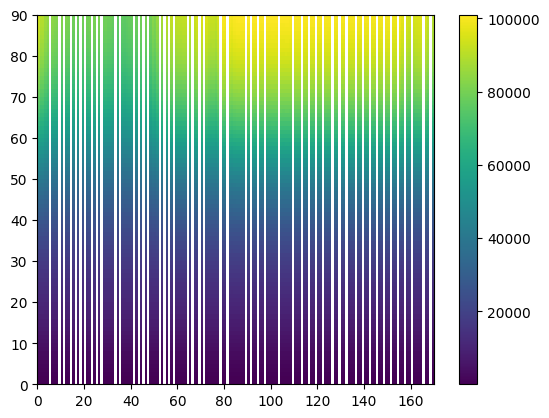

In [178]:
# Read DDH file and store data in a dictionnary
VAR_DDH={}
for i_ddh, name_ddh in enumerate(list_DDH):
    VAR_DDH[name_ddh], VAR_DDH['LONGITUDE'], VAR_DDH['LATITUDE'],VAR_DDH['PRESSURE'] = DDHReadDta(i_ddh=i_ddh,name_ddh=name_ddh,
                                                    i_ech=198,npdt=2,direction=-1,
                                                    n_lon=170, n_lat=84, n_pre=90,dt_model=0.125)


plt.pcolormesh(VAR_DDH['PRESSURE'][:,0,:]);plt.colorbar()

In [179]:
# Fill Missing points by neighborhood average
DDH=DDHMissingPoints(VAR_DDH,170,84,90)

 - Missing Points


In [183]:
np.where(np.isnan(DDH['PRESSURE'][0,:,:]))

(array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3,
        3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 6,
        6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7, 8]),
 array([  5,  27,  33,  35,  66,  71, 103, 122, 126, 145,   3,   5,  27,
         31,  33,  35,  38,  40,  42,  66,  71,  76, 103, 122, 126, 145,
        167,   3,   5,  31,  33,  36,  38,  40,  42,  76, 122, 126, 144,
        149, 167,   6,  31,  33,  36,  38,  75, 127, 133, 144, 149,   3,
          6,  31,  36,  75, 102, 127, 133, 145,   3,  30,  36, 102, 145,
          2,  11,  30,  33,  37, 145,   2,   7,  11,  33,  37, 145,   7]))

In [185]:
DDH['LATITUDE'][0,:,:]

array([[79.99019863, 79.94640053, 80.08247261, ..., 80.0149851 ,
        79.98587965, 79.9567742 ],
       [79.53624507, 79.49368274, 79.4494436 , ...,         nan,
        79.54638539, 79.48757889],
       [78.94660354, 79.04239994, 78.99941778, ...,         nan,
        78.96512614, 79.02154261],
       ...,
       [39.40862116, 39.51017053, 39.53108888, ..., 39.53243053,
        39.49968052, 39.50342488],
       [39.05421425, 38.94236613, 38.96651104, ..., 38.99730355,
        38.98929331, 38.98535663],
       [38.47978999, 38.50747544, 38.47957186, ..., 38.51219764,
        38.49842904, 38.48869879]], shape=(84, 170))

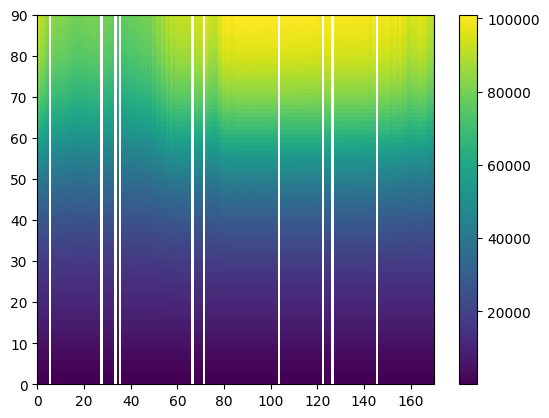

In [180]:
plt.pcolormesh(DDH['PRESSURE'][:,0,:]);plt.colorbar()

In [141]:
# Smooth DDH data
#DDH['PRESSURE']=PR_D
#DH,extension = DDHSmoothing(VAR_DDH,list_DDH, 'Philippe')


# Transform T to Theta tendencies
DDH=DDHTheta(VAR_DDH, list_DDH, PR_D)

 - Theta


In [142]:
# Interpolation from stretched to regular grid
DDH_f,LON_DDH_reg,LAT_DDH_reg,PRE_DDH_reg = DDHRegular(LON_model, LAT_model, PRE_model,LO_D, LA_D, PR_D,DDH, list_DDH)

# Define 3D lon, lat, pre, with regular grid
LON_3D_DDH_reg=np.zeros((PRE_DDH_reg.shape))
LAT_3D_DDH_reg=np.zeros((PRE_DDH_reg.shape))
for i in range(PRE_DDH_reg.shape[0]):
    LON_3D_DDH_reg[i,:,:]=LON_DDH_reg
    LAT_3D_DDH_reg[i,:,:]=LAT_DDH_reg
    
# Add summed variables (all T, all u, all v tendencies)
#DDH_f=DDHAddVar(DDH_f)

# Compute Grad of tendencies
DDHGrad(DDH_f, PRE_DDH_reg, LAT_DDH_reg, LON_DDH_reg)

# Transform list to xArray
DDH_final=Dict2xarray(DDH_f.keys(), DDH_f, PRE_DDH_reg[:,0,0], LAT_DDH_reg, LON_DDH_reg,
               LON_3D_DDH_reg, LAT_3D_DDH_reg, PRE_DDH_reg,dims=('lat','lon'))

 - Interpolation on regular grid
FCTPRECCSCOL


True
True
True
True
True
False
4.3655745685100555e-11
2.9103830456733704e-11


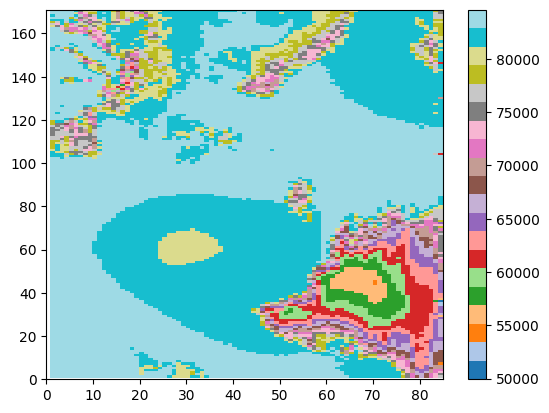

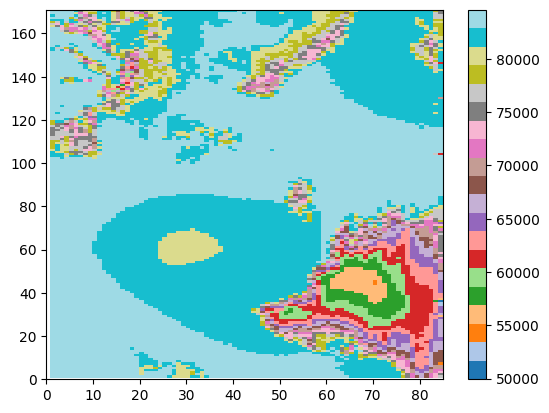

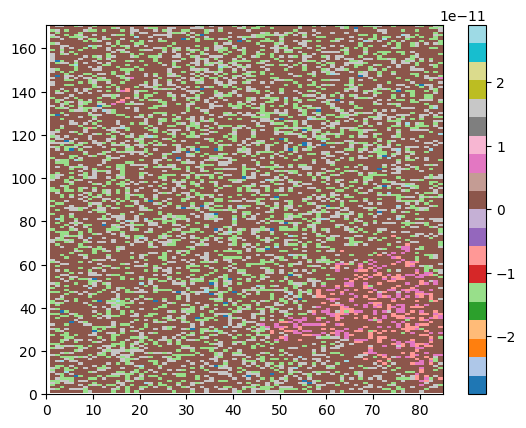

2.9103830456733704e-11
1.4551915228366852e-11
False
0.8871207311941058
0.5976333535722559


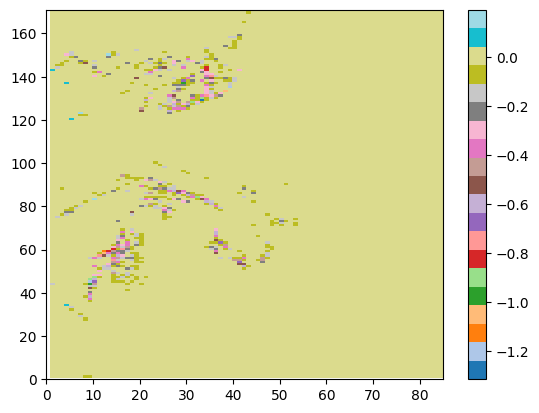

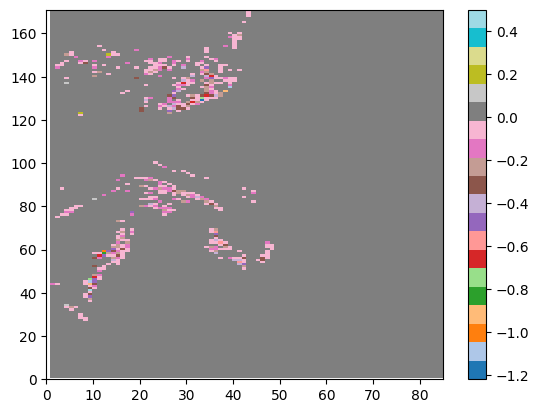

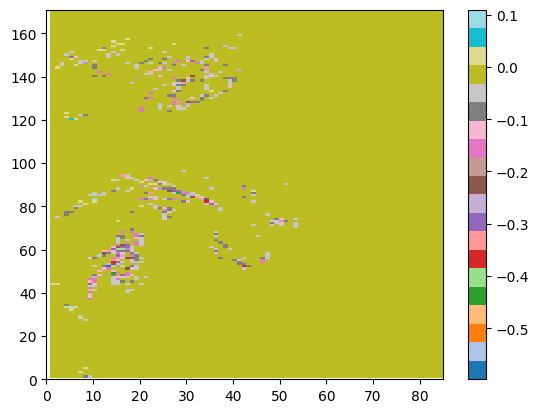

0.38163498862120704
0.0


In [157]:
def graph(a):
    plt.pcolor(a, cmap='tab20'); plt.colorbar(); plt.show()
    
A=[lon2,lat2,pr_ddh,
   x_champ,y_champ,PR_champ,
  # CHAUF,TU,TV,
  # CHAUFX,CHAUFY,CHAUFZ,
  # CHAUFX_V,CHAUFY_U,
  # CHAUFZ_U,CHAUFZ_V,
   
   CHAUF_1,#CHAUFGX_1,CHAUFGY_1,CHAUFGZ_1,
   #CHAUF_2,CHAUFGX_2,CHAUFGY_2,CHAUFGZ_2,
   #CHAUF_3,CHAUFGX_3,CHAUFGY_3,CHAUFGZ_3,
   #CHAUF_4,CHAUFGX_4,CHAUFGY_4,CHAUFGZ_4,
   #CHAUF_5,CHAUFGX_5,CHAUFGY_5,CHAUFGZ_5,
   #CHAUF_6,CHAUFGX_6,CHAUFGY_6,CHAUFGZ_6,
   #CHAUF_7,CHAUFGX_7,CHAUFGY_7,CHAUFGZ_7,
   #CHAUF_8,CHAUFGX_8,CHAUFGY_8,CHAUFGZ_8,
   #CHAUF_9,CHAUFGX_9,CHAUFGY_9,CHAUFGZ_9,
   #CHAUF_10,CHAUFGX_10,CHAUFGY_10,CHAUFGZ_10,
   #CHAUF_11,CHAUFGX_11,CHAUFGY_11,CHAUFGZ_11,
   #CHAUF_12,CHAUFGX_12,CHAUFGY_12,CHAUFGZ_12,
   #CHAUF_13,CHAUFGY_13,
   #CHAUF_14,CHAUFGY_14,
   #CHAUF_15,CHAUFGX_15,
   #CHAUF_16,CHAUFGX_16
  ]
B=[LON_model[20:],LAT_model[16:],pr_ddh, #PRE_DDH_reg[:,16:,20:].T,
   
   LON_DDH_reg[16:,20:].T,LAT_DDH_reg[16:,20:].T, DDH_final['PRESSURE'][:,16:,20:].T,
   #DDH_final['chauf'][:,16:,20:].T,DDH_final['tu'][:,16:,20:].T,DDH_final['tv'][:,16:,20:].T,
   #DDH_final['dchaufdx_P'][:,16:,20:].T,DDH_final['dchaufdy_P'][:,16:,20:].T,DDH_final['dchaufdP'][:,16:,20:].T,
   #DDH_final['dtvdx_P'][:,16:,20:].T,DDH_final['dtudy_P'][:,16:,20:].T,
   #DDH_final['dtudP'][:,16:,20:].T,DDH_final['dtvdP'][:,16:,20:].T,
   DDH_final['FCTPRECCSCOL'][:,16:,20:].T,      DDH_final['dFCTPRECCSCOLdx_P'][:,16:,20:].T,
   DDH_final['dFCTPRECCSCOLdy_P'][:,16:,20:].T, DDH_final['dFCTPRECCSCOLdP'][:,16:,20:].T,
 #  DDH_final['FCTPRECCSCON'][:,16:,20:].T,DDH_final['dFCTPRECCSCONdx_P'][:,16:,20:].T,
 #  DDH_final['dFCTPRECCSCONdy_P'][:,16:,20:].T, DDH_final['dFCTPRECCSCONdP'][:,16:,20:].T,
 #  DDH_final['FCTPRECCSSTL'][:,16:,20:].T,DDH_final['dFCTPRECCSSTLdx_P'][:,16:,20:].T,
 #  DDH_final['dFCTPRECCSSTLdy_P'][:,16:,20:].T, DDH_final['dFCTPRECCSSTLdP'][:,16:,20:].T,
 #  DDH_final['FCTPRECCSSTN'][:,16:,20:].T,DDH_final['dFCTPRECCSSTNdx_P'][:,16:,20:].T,
 #  DDH_final['dFCTPRECCSSTNdy_P'][:,16:,20:].T, DDH_final['dFCTPRECCSSTNdP'][:,16:,20:].T,
 #  DDH_final['FCTPRECICOL'][:,16:,20:].T,DDH_final['dFCTPRECICOLdx_P'][:,16:,20:].T,
 #  DDH_final['dFCTPRECICOLdy_P'][:,16:,20:].T, DDH_final['dFCTPRECICOLdP'][:,16:,20:].T,
 #  DDH_final['FCTPRECICON'][:,16:,20:].T,DDH_final['dFCTPRECICONdx_P'][:,16:,20:].T,
 #  DDH_final['dFCTPRECICONdy_P'][:,16:,20:].T, DDH_final['dFCTPRECICONdP'][:,16:,20:].T,
 #  DDH_final['FCTPRECISTL'][:,16:,20:].T,DDH_final['dFCTPRECISTLdx_P'][:,16:,20:].T,
 #  DDH_final['dFCTPRECISTLdy_P'][:,16:,20:].T, DDH_final['dFCTPRECISTLdP'][:,16:,20:].T,
 #  DDH_final['FCTPRECISTN'][:,16:,20:].T,DDH_final['dFCTPRECISTNdx_P'][:,16:,20:].T,
 #  DDH_final['dFCTPRECISTNdy_P'][:,16:,20:].T, DDH_final['dFCTPRECISTNdP'][:,16:,20:].T,
 #  DDH_final['FCTRAYSOL1'][:,16:,20:].T,DDH_final['dFCTRAYSOL1dx_P'][:,16:,20:].T,
 #  DDH_final['dFCTRAYSOL1dy_P'][:,16:,20:].T, DDH_final['dFCTRAYSOL1dP'][:,16:,20:].T,
 #  DDH_final['FCTRAYTER1'][:,16:,20:].T,DDH_final['dFCTRAYTER1dx_P'][:,16:,20:].T,
 #  DDH_final['dFCTRAYTER1dy_P'][:,16:,20:].T, DDH_final['dFCTRAYTER1dP'][:,16:,20:].T,
 #  DDH_final['FCTTUR'][:,16:,20:].T,DDH_final['dFCTTURdx_P'][:,16:,20:].T,
 #  DDH_final['dFCTTURdy_P'][:,16:,20:].T, DDH_final['dFCTTURdP'][:,16:,20:].T,
 #  DDH_final['FCTTURCONV'][:,16:,20:].T,DDH_final['dFCTTURCONVdx_P'][:,16:,20:].T,
 #  DDH_final['dFCTTURCONVdy_P'][:,16:,20:].T, DDH_final['dFCTTURCONVdP'][:,16:,20:].T,
 #  DDH_final['FUUTUR'][:,16:,20:].T,DDH_final['dFUUTURdy_P'][:,16:,20:].T,
 #  DDH_final['FUUTURCONV'][:,16:,20:].T,DDH_final['dFUUTURCONVdy_P'][:,16:,20:].T,
 #  DDH_final['FVVTUR'][:,16:,20:].T,DDH_final['dFVVTURdx_P'][:,16:,20:].T,
 #  DDH_final['FVVTURCONV'][:,16:,20:].T,DDH_final['dFVVTURCONVdx_P'][:,16:,20:].T,
  ]

nb_digit=15
for a,b in zip(A,B):
    #print(np.array_equal(np.round(a,nb_digit),np.round(b,nb_digit), equal_nan=True)) #all(a == b))
    ok=np.nanmax(np.abs(a-b))<10**(-1*nb_digit)
    print(ok)
    
    if not ok:
        #print(a,b)
        print(np.nanmax(np.abs(a-b)))
        
        ilev=70
        print(np.nanmax(np.abs((a-b)[:,:,ilev])))
        graph(a[:,:,ilev]); graph(b[:,:,ilev]);graph((a-b)[:,:,ilev])
        
        ilev=89
        print(np.nanmax(np.abs((a-b)[:,:,ilev])))
        
        ilev=52
        print(np.nanmax(np.abs((a-b)[:,:,ilev])))